In [3]:
# ============================================================
# DATA SPLIT
# ============================================================
import os, shutil, random

SRC_DIR  = "/kaggle/input/datasets/kaggleanshita/resnet1/DAT-SEGREGATION"
DEST_DIR = "/kaggle/working/ppmi-datscan-ntua-split"
TRAIN_RATIO = 0.8
SEED = 42

random.seed(SEED)

for cls in ["NONPD", "PD"]:
    src_cls = os.path.join(SRC_DIR, cls)
    files = os.listdir(src_cls)
    random.shuffle(files)

    split_idx = int(len(files) * TRAIN_RATIO)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    for f in train_files:
        os.makedirs(f"{DEST_DIR}/train/{cls}", exist_ok=True)
        shutil.copy(os.path.join(src_cls, f), os.path.join(DEST_DIR, "train", cls, f))

    for f in test_files:
        os.makedirs(f"{DEST_DIR}/test/{cls}", exist_ok=True)
        shutil.copy(os.path.join(src_cls, f), os.path.join(DEST_DIR, "test", cls, f))

print("✅ Train–Test split completed")

✅ Train–Test split completed


In [4]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [5]:
# ============================================================
# MIXED PRECISION + SEED
# ============================================================
mixed_precision.set_global_policy("mixed_float16")
tf.random.set_seed(42)
np.random.seed(42)


# ============================================================
# CONFIG
# ============================================================
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
EPOCHS_STAGE1 = 100
EPOCHS_STAGE2 = 100
DATA_DIR = DEST_DIR


# ============================================================
# DATA GENERATORS
# ============================================================
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
).flow_from_directory(
    f"{DATA_DIR}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    f"{DATA_DIR}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)

Found 1525 images belonging to 2 classes.
Found 383 images belonging to 2 classes.


In [6]:
# ============================================================
# APPLY SMOTE
# ============================================================
print("\nApplying SMOTE...")

X_train = []
y_train = []

for i in range(len(train_gen)):
    x_batch, y_batch = train_gen[i]
    X_train.append(x_batch)
    y_train.append(y_batch)

X_train = np.vstack(X_train)
y_train = np.vstack(y_train)

print("Before SMOTE:", np.sum(y_train, axis=0))

y_labels = np.argmax(y_train, axis=1)

# Flatten for SMOTE
n_samples = X_train.shape[0]
X_flat = X_train.reshape(n_samples, -1)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_flat, y_labels)

# Reshape back
X_res = X_res.reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 3)
y_res = tf.keras.utils.to_categorical(y_res, NUM_CLASSES)

print("After SMOTE:", np.sum(y_res, axis=0))


Applying SMOTE...
Before SMOTE: [ 356. 1169.]
After SMOTE: [1169. 1169.]


In [7]:
# ============================================================
# MODEL — ResNet50
# ============================================================
base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
model = models.Model(base.input, outputs)

In [8]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,770,690 (94.49 MB)

 Trainable params: 1,181,954 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [9]:
# ============================================================
# STAGE 1 TRAIN
# ============================================================
model.compile(
    optimizer=Adam(3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    EarlyStopping(monitor="loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="loss", patience=2, factor=0.5)
]

history_stage1 = model.fit(
    X_res, y_res,
    batch_size=BATCH_SIZE,
    validation_data=test_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7368 - auc: 0.7994 - loss: 0.7689

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


147/147 ━━━━━━━━━━━━━━━━━━━━ 36s 139ms/step - accuracy: 0.7372 - auc: 0.7999 - loss: 0.7677 - val_accuracy: 0.7493 - val_auc: 0.8321 - val_loss: 0.6317 - learning_rate: 3.0000e-04
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8387 - auc: 0.9182 - loss: 0.4696 - val_accuracy: 0.6345 - val_auc: 0.7477 - val_loss: 0.8535 - learning_rate: 3.0000e-04
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8862 - auc: 0.9563 - loss: 0.3459 - val_accuracy: 0.7389 - val_auc: 0.8363 - val_loss: 0.6529 - learning_rate: 3.0000e-04
Epoch 4/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8957 - auc: 0.9596 - loss: 0.3351 - val_accuracy: 0.8407 - val_auc: 0.9136 - val_loss: 0.4635 - learning_rate: 3.0000e-04
Epoch 5/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9085 - auc: 0.9714 - loss: 0.2920 - val_accuracy: 0.7859 - val_auc: 0.8814 - val_loss: 0.5397 - learning_rate: 3.0000e-04
Epoch 6/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accu

In [10]:
# ============================================================
# STAGE 2 FINE TUNE
# ============================================================
for layer in base.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_stage2 = model.fit(
    X_res, y_res,
    batch_size=BATCH_SIZE,
    validation_data=test_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 70s 231ms/step - accuracy: 0.8601 - auc: 0.9198 - loss: 0.7579 - val_accuracy: 0.8773 - val_auc: 0.9385 - val_loss: 0.7237 - learning_rate: 3.0000e-05
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9575 - auc: 0.9904 - loss: 0.1775 - val_accuracy: 0.8460 - val_auc: 0.9158 - val_loss: 0.7795 - learning_rate: 3.0000e-05
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9875 - auc: 0.9992 - loss: 0.0760 - val_accuracy: 0.8486 - val_auc: 0.9058 - val_loss: 0.8161 - learning_rate: 3.0000e-05
Epoch 4/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9975 - auc: 0.9999 - loss: 0.0509 - val_accuracy: 0.8616 - val_auc: 0.9193 - val_loss: 0.7592 - learning_rate: 3.0000e-05
Epoch 5/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0454 - val_accuracy: 0.8721 - val_auc: 0.9308 - val_loss: 0.6825 - learning_rate: 3.0000e-05
Epoch 6/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms

In [11]:
# ============================================================
# EVALUATION
# ============================================================
test_loss, test_acc, test_auc = model.evaluate(test_gen)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC: {test_auc:.3f}")

y_probs = model.predict(test_gen)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8483 - auc: 0.8899 - loss: 1.1776

Test Accuracy: 88.77%
Test AUC: 0.934
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step
              precision    recall  f1-score   support

       NONPD       0.72      0.86      0.78        90
          PD       0.95      0.90      0.92       293

    accuracy                           0.89       383
   macro avg       0.84      0.88      0.85       383
weighted avg       0.90      0.89      0.89       383



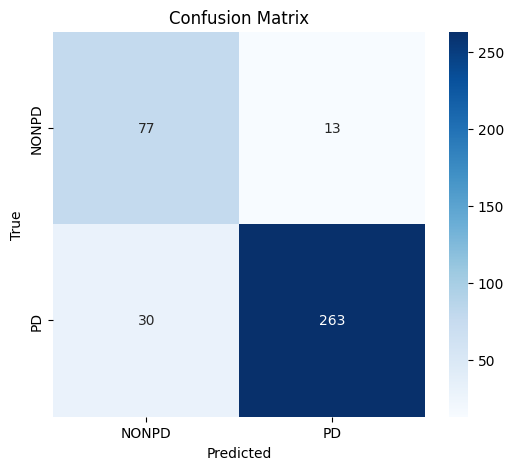

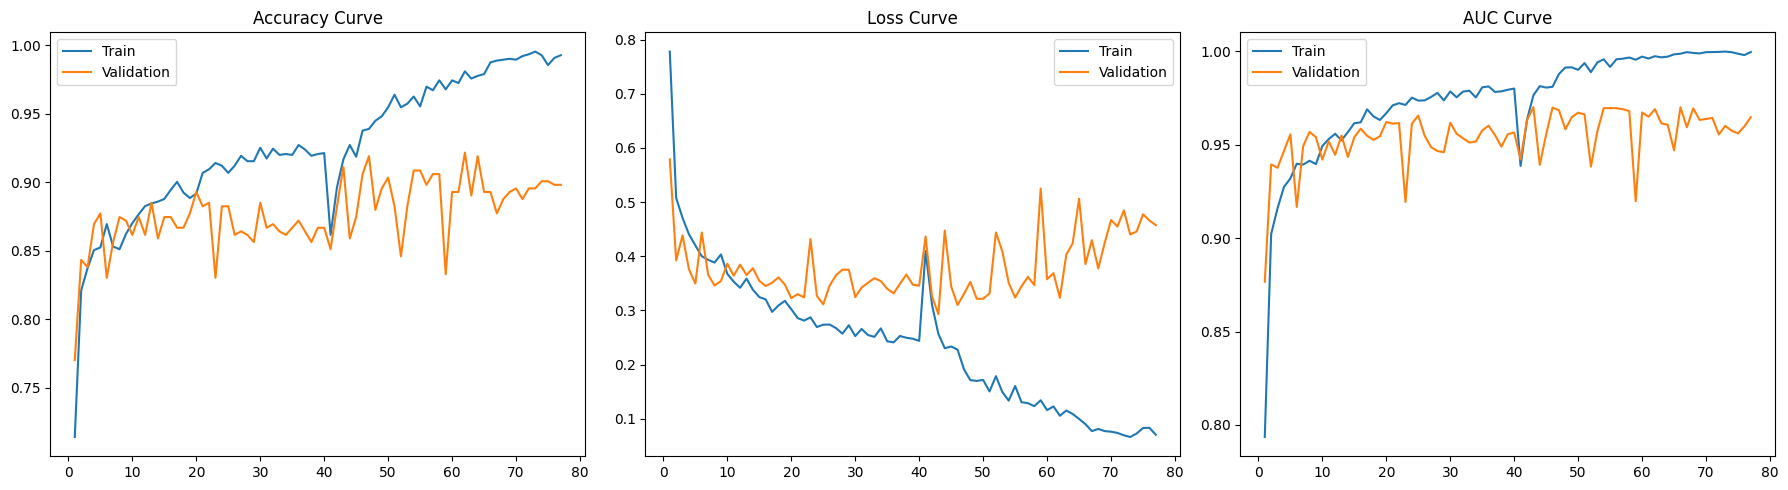

In [14]:
# ============================================================
# DISPLAY RESULTS 
# ============================================================

# ---------- CONFUSION MATRIX ----------
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# ---------- TRAINING GRAPHS ----------
epochs = range(1, len(history["accuracy"]) + 1)

plt.figure(figsize=(18,5))

# Accuracy
plt.subplot(1,3,1)
plt.plot(epochs, history["accuracy"], label="Train")
plt.plot(epochs, history["val_accuracy"], label="Validation")
plt.title("Accuracy Curve")
plt.legend()

# Loss
plt.subplot(1,3,2)
plt.plot(epochs, history["loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.title("Loss Curve")
plt.legend()

# AUC
plt.subplot(1,3,3)
plt.plot(epochs, history["auc"], label="Train")
plt.plot(epochs, history["val_auc"], label="Validation")
plt.title("AUC Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# SAVE RESULTS + ZIP
# ============================================================
import pandas as pd
import zipfile
os.makedirs("results", exist_ok=True)

# Predictions
pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred
}).to_csv("results/predictions.csv", index=False)

# Metrics
pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )
).transpose().to_csv("results/metrics.csv")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
np.save("results/confusion_matrix.npy", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png")
plt.close()

# Training Curves
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(history["accuracy"])
plt.plot(history["val_accuracy"])
plt.title("Accuracy")

plt.subplot(1,3,2)
plt.plot(history["loss"])
plt.plot(history["val_loss"])
plt.title("Loss")

plt.subplot(1,3,3)
plt.plot(history["auc"])
plt.plot(history["val_auc"])
plt.title("AUC")

plt.tight_layout()
plt.savefig("results/training_curves.png")
plt.close()

# Save model
model.save("results/resnet50_model.h5")

# ZIP creation
zip_path = "resnet50_results.zip"

with zipfile.ZipFile(zip_path, "w") as z:
    for root, dirs, files in os.walk("results"):
        for file in files:
            z.write(os.path.join(root, file))

print("✅ ZIP created")

from IPython.display import FileLink
display(FileLink(zip_path))


✅ ZIP created


/kaggle/working/resnet50_results.zip